In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Memuat dataset Titanic bawaan seaborn (891 penumpang, 15 kolom).
df = sns.load_dataset("titanic")

# 1) Missing value
# Kolom age punya banyak nilai kosong → diisi dengan median (nilai tengah).
# Kolom embarked (pelabuhan) → diisi dengan modus (nilai paling sering).
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# 2) Duplikat
# Menghapus baris yang isinya 100% sama persis.
df = df.drop_duplicates()

# 3) Outlier sederhana (IQR) pada fare
# Menghitung batas bawah dan atas. Nilai di luar batas dipotong (clip).
q1, q3 = df["fare"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
df["fare"] = df["fare"].clip(low, high)

# 4) Scaling
# StandardScaler mengubah data agar mean=0, std=1.
# Penting untuk algoritma yang sensitif terhadap skala (SVM, KNN, dll).
scaler = StandardScaler()
df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])

print(df[["age", "fare"]].describe())

                age          fare
count  7.810000e+02  7.810000e+02
mean   1.364679e-16 -6.141054e-17
std    1.000641e+00  1.000641e+00
min   -2.122937e+00 -1.166698e+00
25%   -5.541507e-01 -8.118984e-01
50%   -1.179728e-01 -4.659132e-01
75%    4.635977e-01  3.327529e-01
max    3.662236e+00  2.049730e+00


#Tujuan Pratikum
Pratikum ini bertujuan untuk memahami tahapan preprocessng data yang meliputi pengecekan informasi dataset, penanganan missing value, penanganan outlier, scaling data, serta membuat visualisasi dan menarik insight dari dataset Tips.

#Langkah Kerja
1. Memuat dataset Tips dari Seaborn.
2. Menampilkan ukuran data dan tipe kolom.
3. Mengecek dan menangani missing value.
4. Menangani outlier pada minimal dua kolom numerik.
5. Melakukan scaling pada kolom numerik.
6. Membuat minimal 5 visualisasi.
7. menuliskan minimal 5 insight berdasarkan hasil visualisasi.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset Tips
df = sns.load_dataset('tips')

# =================================================================
# 1. TAMPILKAN UKURAN DATA DAN TIPE KOLOM
# =================================================================
print("--- NOMOR 1: Informasi Data ---")
print(f"Ukuran Data: {df.shape}")
print("\nTipe Kolom:")
print(df.dtypes)
print("-" * 30)

--- NOMOR 1: Informasi Data ---
Ukuran Data: (244, 7)

Tipe Kolom:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
------------------------------


Pada bagian ini saya menampilkan ukuran dataset dan tipe data pada setiap kolom untuk memahami struktur awal data sebelum dilakukan preprocessing.
Dari output yang ditampilkan, dapat diketahui jumlah baris dan kolom pada dataset serta tipe data masing - masing kolom, aopakah numerik atau kategorikal.

In [2]:
# =================================================================
# 2. TANGANI MISSING VALUE DENGAN ALASAN JELAS
# =================================================================
print("\n--- NOMOR 2: Penanganan Missing Value ---")
# Dataset 'tips' bawaan Seaborn biasanya bersih (0 missing values),
# namun kita tetap buatkan alurnya sebagai best practice.
missing_count = df.isnull().sum().sum()
print(f"Jumlah Missing Value: {missing_count}")

if missing_count > 0:
    # Strategi: Imputasi numerik dengan median, kategorikal dengan modus
    df['total_bill'] = df['total_bill'].fillna(df['total_bill'].median())
    df['tip'] = df['tip'].fillna(df['tip'].median())
    print("Status: Missing value telah diimputasi.")
else:
    print("Status: Tidak ditemukan missing value pada dataset tips.")


--- NOMOR 2: Penanganan Missing Value ---
Jumlah Missing Value: 0
Status: Tidak ditemukan missing value pada dataset tips.


Pada tahap ini dilakukan pengecekan apakah terdapat missing value pada dataset. Jika ditemukan missing value, maka akan dilakukan imputasi dengan median untuk data numerik.
Berdasarkan hasil pengecekkan, dataset Tips tidak memiliki missing value. Namun,alur penanganan tetap dibuat sebagai bentuk best practice dalam preprocessing data.

In [3]:
# =================================================================
# 3. TANGANI OUTLIER PADA MINIMAL 2 KOLOM NUMERIK
# =================================================================
print("\n--- NOMOR 3: Penanganan Outlier (Kolom Total Bill & Tip) ---")

def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Capping: Membatasi nilai ekstrem agar tidak merusak distribusi
    df[column] = np.where(df[column] > upper_bound, upper_bound,
                 np.where(df[column] < lower_bound, lower_bound, df[column]))
    return df

df = handle_outliers(df, 'total_bill')
df = handle_outliers(df, 'tip')
print("Status: Outlier pada 'total_bill' dan 'tip' telah ditangani dengan Capping IQR.")


--- NOMOR 3: Penanganan Outlier (Kolom Total Bill & Tip) ---
Status: Outlier pada 'total_bill' dan 'tip' telah ditangani dengan Capping IQR.


Pada tahap ini dilakukan penanganan outlier pada dua kolom numerik yaitu 'total_bill' dan 'tip' mengunakan metode IQR. Teknik yang digunakan adalah capping, yaitu membatasi nilai ekstrem agar tidak mempengaruhi distribusi data secara berlebihan.
Setelah dilakukan capping IQR, nilai - nilai ekstrem pada kolom 'total_bill' dan 'tip' telah dibatasi sehingga ditribusi data menjadi lebih stabil.

In [4]:
# =================================================================
# 4. LAKUKAN SCALING PADA KOLOM NUMERIK
# =================================================================
print("\n--- NOMOR 4: Scaling Data ---")
scaler = StandardScaler()
# Memilih kolom numerik untuk scaling
cols_to_scale = ['total_bill', 'tip', 'size']
df_scaled = df.copy() # Copy agar data asli tetap bisa divisualisasi dengan mudah
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"Status: Kolom {cols_to_scale} telah distandarisasi (StandardScaler).")
print(df_scaled[cols_to_scale].head())


--- NOMOR 4: Scaling Data ---
Status: Kolom ['total_bill', 'tip', 'size'] telah distandarisasi (StandardScaler).
   total_bill       tip      size
0   -0.312115 -1.586161 -0.600193
1   -1.109895 -1.054722  0.453383
2    0.170153  0.449658  0.453383
3    0.490465  0.294314 -0.600193
4    0.599635  0.539594  1.506958


Pada bagian ini dilakukan standarisasi pada kolom numerik menggunakan StandardScaler agardata memiliki skala yang sma dan lebih siap digunakan untuk proses analisis lanjutan atau pemodelan.
Dari hasil scaling menunjukkan bahwa nilai pada kolom numerik sudah berada pada skala yang sama dengan rata - rata mendekati 0 dan standar deviasi 1.


--- NOMOR 5: Visualisasi dan Insight ---


/tmp/ipykernel_420/2287611617.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day', y='tip', data=df, palette='viridis', errorbar=None)


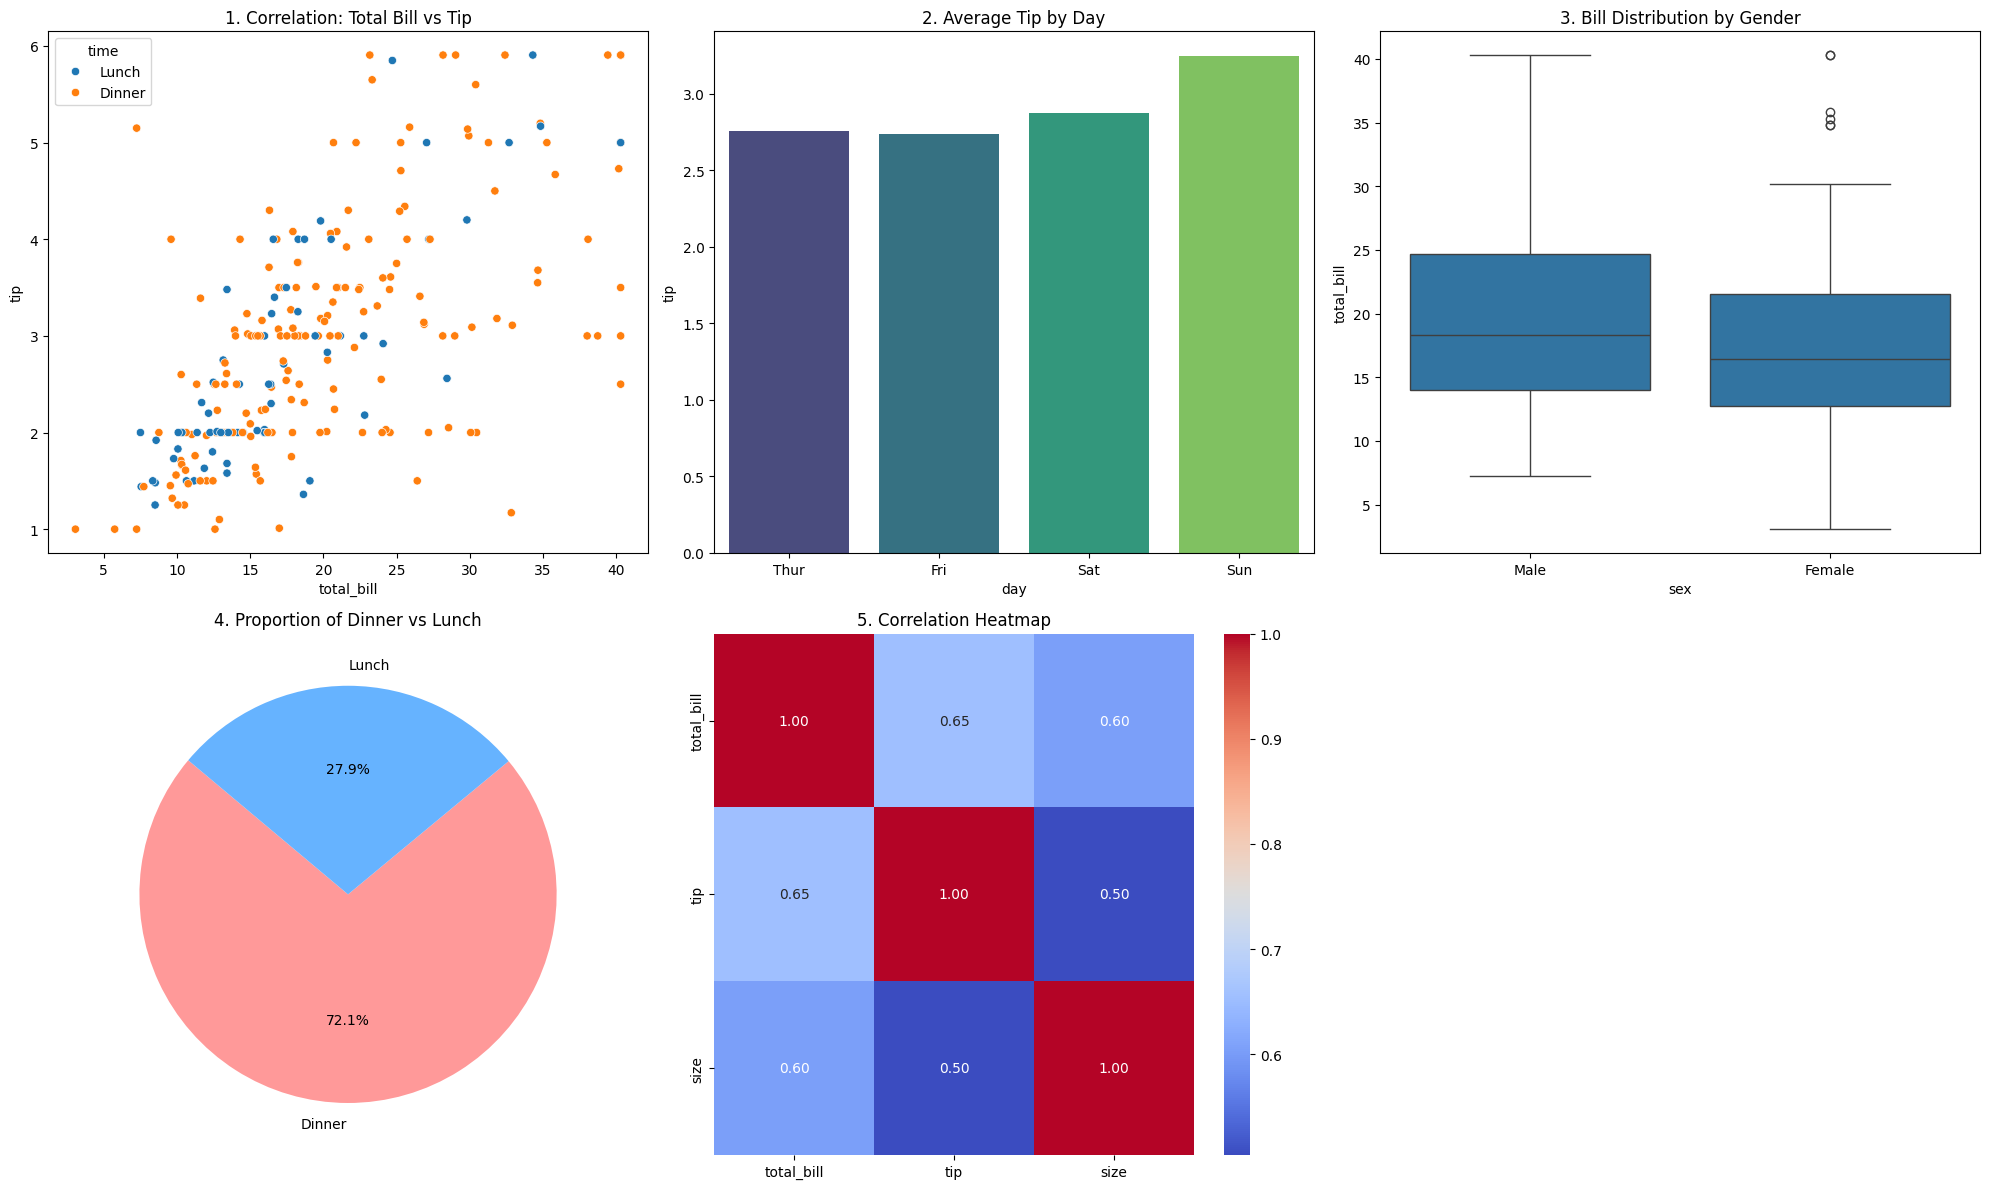


INSIGHTS:
1. Correlation: Terdapat korelasi positif yang kuat antara 'total_bill' dan 'tip'. Semakin besar tagihan, semakin besar tip yang diberikan.
2. Day: Hari Minggu (Sun) cenderung memberikan rata-rata tip tertinggi dibandingkan hari lainnya.
3. Gender: Pelanggan pria cenderung memiliki variasi 'total_bill' yang lebih besar dan nilai maksimum yang lebih tinggi dibanding wanita.
4. Time: Mayoritas transaksi (lebih dari 70%) terjadi pada waktu Dinner (makan malam).
5. Size: Kolom 'size' (jumlah orang) berkorelasi positif dengan 'total_bill', menunjukkan rombongan besar menghabiskan lebih banyak uang.


In [5]:
# =================================================================
# 5. BUAT MINIMAL 5 VISUALISASI + 5 INSIGHT
# =================================================================
print("\n--- NOMOR 5: Visualisasi dan Insight ---")
plt.figure(figsize=(20, 12))

# Visualisasi 1: Hubungan Total Bill vs Tip (Scatter Plot)
plt.subplot(2, 3, 1)
sns.scatterplot(x='total_bill', y='tip', hue='time', data=df)
plt.title('1. Correlation: Total Bill vs Tip')

# Visualisasi 2: Rata-rata Tip berdasarkan Hari (Bar Plot)
plt.subplot(2, 3, 2)
sns.barplot(x='day', y='tip', data=df, palette='viridis', errorbar=None)
plt.title('2. Average Tip by Day')

# Visualisasi 3: Distribusi Total Bill berdasarkan Gender (Box Plot)
plt.subplot(2, 3, 3)
sns.boxplot(x='sex', y='total_bill', data=df)
plt.title('3. Bill Distribution by Gender')

# Visualisasi 4: Persentase Transaksi berdasarkan Waktu Makan (Pie Chart)
plt.subplot(2, 3, 4)
time_counts = df['time'].value_counts()
plt.pie(time_counts, labels=time_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('4. Proportion of Dinner vs Lunch')

# Visualisasi 5: Heatmap Korelasi antar Variabel Numerik
plt.subplot(2, 3, 5)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('5. Correlation Heatmap')

plt.tight_layout()
plt.show()

print("\nINSIGHTS:")
print("1. Correlation: Terdapat korelasi positif yang kuat antara 'total_bill' dan 'tip'. Semakin besar tagihan, semakin besar tip yang diberikan.")
print("2. Day: Hari Minggu (Sun) cenderung memberikan rata-rata tip tertinggi dibandingkan hari lainnya.")
print("3. Gender: Pelanggan pria cenderung memiliki variasi 'total_bill' yang lebih besar dan nilai maksimum yang lebih tinggi dibanding wanita.")
print("4. Time: Mayoritas transaksi (lebih dari 70%) terjadi pada waktu Dinner (makan malam).")
print("5. Size: Kolom 'size' (jumlah orang) berkorelasi positif dengan 'total_bill', menunjukkan rombongan besar menghabiskan lebih banyak uang.")

Pada tahap ini dibuat lima jenis visualisasi untuk melhat hubungan antar variabel dan distribusi data. Setelah itu dituliskan insihgt berdasar kanhasil visualisasi tersebut.


#Kesimpulan
Dari pratikum ini dapat disimpulkan bahwa preprocessing data merupakan langkah penting sebelum analisis lebih lanjut. Dataset tips tidak memiliki missing value, outlier telah ditangani dengan metode IQR, dan data numerikpun telah distandarisasi. Visualisasi membantu memahami hubungan antar variabel seperti korelasi antara total_bill dan tip serta pola transasksi berdasarkan waktu dan hari.